# Libraries

In [1]:
# Data Preparation
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
from transformers import AutoTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Device

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


# Data Preprocessing & Preparation

In [3]:
# Initialize 
# Load a pre-trained tokenizer
from nltk.tokenize import word_tokenize
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
stop_words_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [4]:
from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# Preprocessing pipelien
transform_pipeline = preprocessing.Compose([
    preprocessing.Lowercase(),
    preprocessing.Tokenize(tokenizer),
    preprocessing.StopwordsRemoval(stop_words_list),
    preprocessing.POStagging(),
    preprocessing.Lemmatization(lemmatizer), 
])

In [5]:
# 1. Load dataset and apply prior Transform 
train_dataset = IMDBDataset(base_path='aclImdb', size=2000, train=True, transform=transform_pipeline)
test_dataset = IMDBDataset(base_path='aclImdb', size=1000, train=False, transform=transform_pipeline)
print(train_dataset.df.head())

# 2. Extract preprocessed texts and labels
train_input = [train_dataset[i][0] for i in range(len(train_dataset))]
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

test_input = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

# 3. Apply TF-IDF to the whole dataset
vectorizer = TfidfVectorizer(max_features=128)
train_embedded_features = vectorizer.fit_transform(train_input).toarray()
test_embedded_features = vectorizer.transform(test_input).toarray() #use same transformer as train set

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# 5. Construct dataset for dataloader
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

      id                                             review  score sentiment
0   8071  This film deals with the Irish rebellion in th...      9  positive
1   4254  I really enjoyed this movie. The script is fre...      9  positive
2  11800  Powers Boothe turns in a stellar performance a...      8  positive
3     36  Another good Stooge short!Christine McIntyre i...     10  positive
4  10236  Hello Dave Burning Paradise is a film for anyo...      8  positive


Token indices sequence length is longer than the specified maximum sequence length for this model (746 > 512). Running this sequence through the model will result in indexing errors


# Split data for training and validation

In [6]:
# Split train_dataset into training and validation set
from sklearn.model_selection import train_test_split

#Split dataset for train and validation
train_size = int(0.8 * len(train_dataset))
train_indices, val_indices = train_test_split(list(range(len(train_dataset))),
                                              test_size=len(train_dataset) - train_size,
                                              stratify=y_train_tensor,
                                              random_state=42)

trainset = torch.utils.data.Subset(train_dataset, train_indices)
valset = torch.utils.data.Subset(train_dataset, val_indices)

#DataLoader to handle batching and shuffling
batch_size = 32
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Model

# Training + Evaluation

In [7]:
from train_test import train_model, test_model, plot_accuracy_loss, plot_confusion_matrix
import classifier as clf

SimpleClassifier(
  (fc1): Linear(in_features=128, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


6552 total parameters.
6552 training parameters.




  0%|          | 0/64 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  2%|▏         | 1/64 [00:00<00:09,  6.83it/s]

| Epoch: [1/64] | Train: Loss 0.6906 Accuracy : 0.5387 | Val: Loss 0.6763 Accuracy : 0.7075



  8%|▊         | 5/64 [00:00<00:02, 21.14it/s]

| Epoch: [2/64] | Train: Loss 0.6553 Accuracy : 0.7137 | Val: Loss 0.6272 Accuracy : 0.7325

| Epoch: [3/64] | Train: Loss 0.5948 Accuracy : 0.7506 | Val: Loss 0.5641 Accuracy : 0.7475

| Epoch: [4/64] | Train: Loss 0.5383 Accuracy : 0.7594 | Val: Loss 0.5259 Accuracy : 0.7525

| Epoch: [5/64] | Train: Loss 0.5058 Accuracy : 0.7638 | Val: Loss 0.5100 Accuracy : 0.7525

| Epoch: [6/64] | Train: Loss 0.4887 Accuracy : 0.7625 | Val: Loss 0.5044 Accuracy : 0.7525

| Epoch: [7/64] | Train: Loss 0.4784 Accuracy : 0.7625 | Val: Loss 0.5033 Accuracy : 0.7575

| Epoch: [8/64] | Train: Loss 0.4713 Accuracy : 0.7662 | Val: Loss 0.5039 Accuracy : 0.7600



...

| Epoch: [45/64] | Train: Loss 0.3183 Accuracy : 0.8725 | Val: Loss 0.5628 Accuracy : 0.7400

| Epoch: [46/64] | Train: Loss 0.3139 Accuracy : 0.8769 | Val: Loss 0.5646 Accuracy : 0.7400

| Epoch: [47/64] | Train: Loss 0.3097 Accuracy : 0.8794 | Val: Loss 0.5672 Accuracy : 0.7400

| Epoch: [48/64] | Train: Loss 0.3055 Accuracy : 0.8812 | Val: Loss 0.5697 Accuracy : 0.7400

| Epoch: [49/64] | Train: Loss 0.3013 Accuracy : 0.8844 | Val: Loss 0.5718 Accuracy : 0.7400

| Epoch: [50/64] | Train: Loss 0.2968 Accuracy : 0.8869 | Val: Loss 0.5743 Accuracy : 0.7400



 89%|████████▉ | 57/64 [00:01<00:00, 31.47it/s]

| Epoch: [51/64] | Train: Loss 0.2925 Accuracy : 0.8881 | Val: Loss 0.5764 Accuracy : 0.7425

| Epoch: [52/64] | Train: Loss 0.2881 Accuracy : 0.8881 | Val: Loss 0.5791 Accuracy : 0.7375

| Epoch: [53/64] | Train: Loss 0.2838 Accuracy : 0.8931 | Val: Loss 0.5816 Accuracy : 0.7350

| Epoch: [54/64] | Train: Loss 0.2795 Accuracy : 0.8950 | Val: Loss 0.5835 Accuracy : 0.7325

| Epoch: [55/64] | Train: Loss 0.2754 Accuracy : 0.8962 | Val: Loss 0.5856 Accuracy : 0.7350

| Epoch: [56/64] | Train: Loss 0.2711 Accuracy : 0.8988 | Val: Loss 0.5879 Accuracy : 0.7350

| Epoch: [57/64] | Train: Loss 0.2669 Accuracy : 0.9031 | Val: Loss 0.5906 Accuracy : 0.7350



100%|██████████| 64/64 [00:02<00:00, 30.48it/s]

| Epoch: [58/64] | Train: Loss 0.2626 Accuracy : 0.9069 | Val: Loss 0.5934 Accuracy : 0.7350

| Epoch: [59/64] | Train: Loss 0.2586 Accuracy : 0.9094 | Val: Loss 0.5955 Accuracy : 0.7350

| Epoch: [60/64] | Train: Loss 0.2545 Accuracy : 0.9137 | Val: Loss 0.5989 Accuracy : 0.7300

| Epoch: [61/64] | Train: Loss 0.2503 Accuracy : 0.9150 | Val: Loss 0.6012 Accuracy : 0.7300

| Epoch: [62/64] | Train: Loss 0.2463 Accuracy : 0.9194 | Val: Loss 0.6045 Accuracy : 0.7300

| Epoch: [63/64] | Train: Loss 0.2420 Accuracy : 0.9219 | Val: Loss 0.6077 Accuracy : 0.7275

| Epoch: [64/64] | Train: Loss 0.2381 Accuracy : 0.9237 | Val: Loss 0.6104 Accuracy : 0.7250


Test accuracy: 0.76


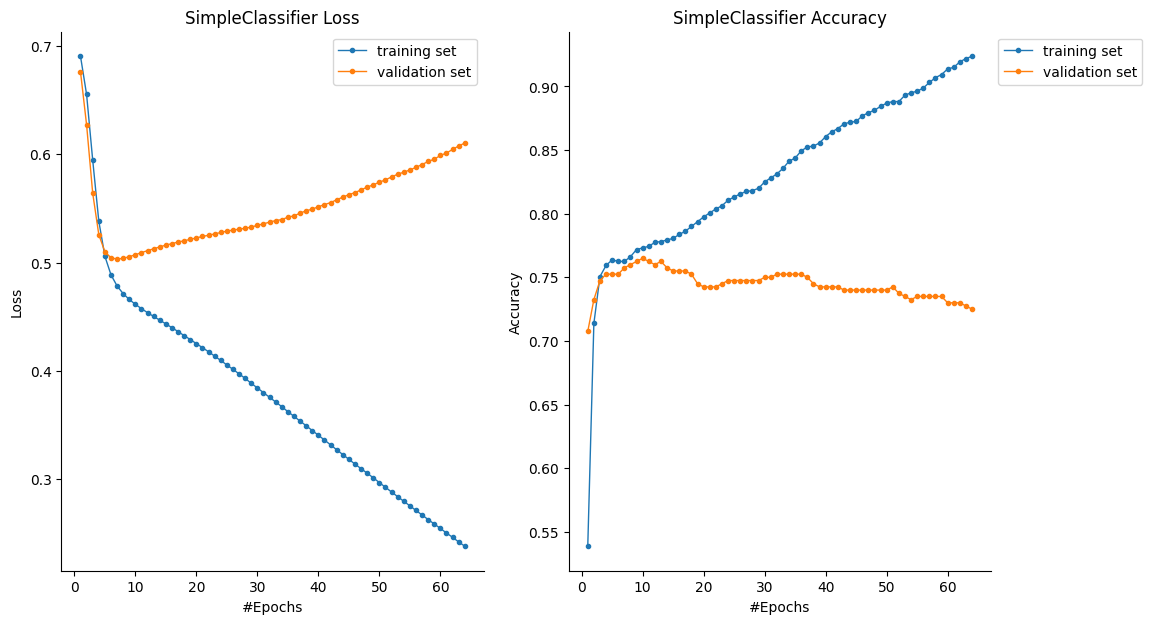

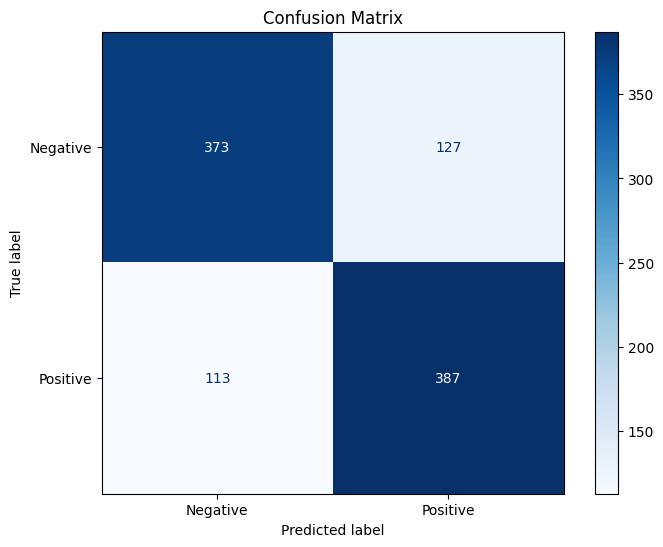

In [8]:
# init paramètre
nb_epochs = 64
optimizer = 'Adam'
lr = 0.001
input_dim = train_dataset.tensors[0].shape[1]
model = clf.SimpleClassifier(input_dim=input_dim).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("SimpleClassifier", train_loss, val_loss, train_acc, val_acc)


plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# LSTM

LSTMClassifier(
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


264450 total parameters.
264450 training parameters.




  2%|▏         | 1/64 [00:00<00:07,  8.80it/s]

| Epoch: [1/64] | Train: Loss 0.6914 Accuracy : 0.5112 | Val: Loss 0.6828 Accuracy : 0.6475

| Epoch: [2/64] | Train: Loss 0.6229 Accuracy : 0.7300 | Val: Loss 0.5422 Accuracy : 0.7250



  5%|▍         | 3/64 [00:00<00:05, 10.87it/s]

| Epoch: [3/64] | Train: Loss 0.4722 Accuracy : 0.7750 | Val: Loss 0.5100 Accuracy : 0.7625



...

| Epoch: [58/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.5845 Accuracy : 0.7425

| Epoch: [59/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.5903 Accuracy : 0.7425

| Epoch: [60/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.5961 Accuracy : 0.7425



 98%|█████████▊| 63/64 [00:05<00:00, 11.00it/s]

| Epoch: [61/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.6018 Accuracy : 0.7425

| Epoch: [62/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.6075 Accuracy : 0.7425

| Epoch: [63/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.6131 Accuracy : 0.7425



100%|██████████| 64/64 [00:05<00:00, 11.43it/s]


| Epoch: [64/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.6186 Accuracy : 0.7425


Test accuracy: 0.736


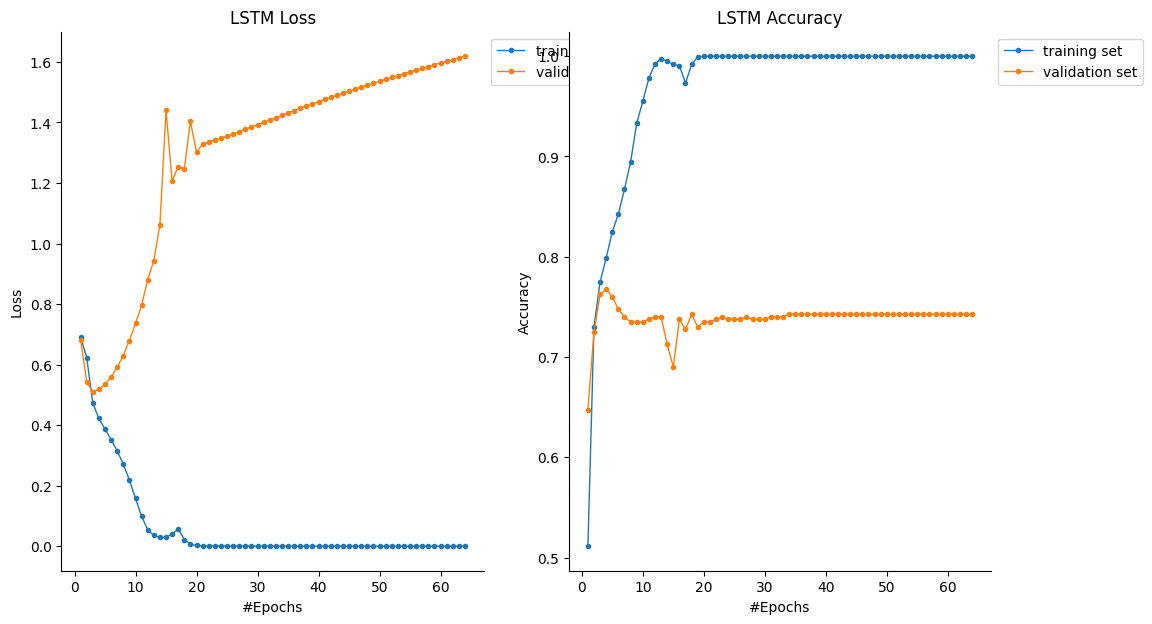

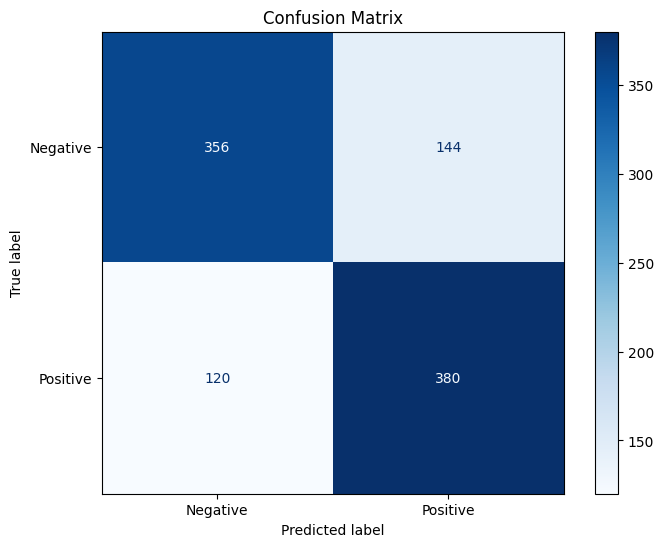

In [9]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMClassifier(input_dim=input_dim, hidden_dim=128, num_layers=2, output_dim=2, bidirectional=False).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Deeper LSTM

DeepLSTMClassifier(
  (lstm): LSTM(128, 128, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1071298 total parameters.
1071298 training parameters.




  0%|          | 0/64 [00:00<?, ?it/s]

  2%|▏         | 1/64 [00:00<00:16,  3.84it/s]

| Epoch: [1/64] | Train: Loss 0.6932 Accuracy : 0.4988 | Val: Loss 0.6917 Accuracy : 0.5000



  3%|▎         | 2/64 [00:00<00:16,  3.76it/s]

...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.6294 Accuracy : 0.7400



 98%|█████████▊| 63/64 [00:19<00:00,  2.65it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.6397 Accuracy : 0.7400



100%|██████████| 64/64 [00:20<00:00,  3.17it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.6497 Accuracy : 0.7400


Test accuracy: 0.746


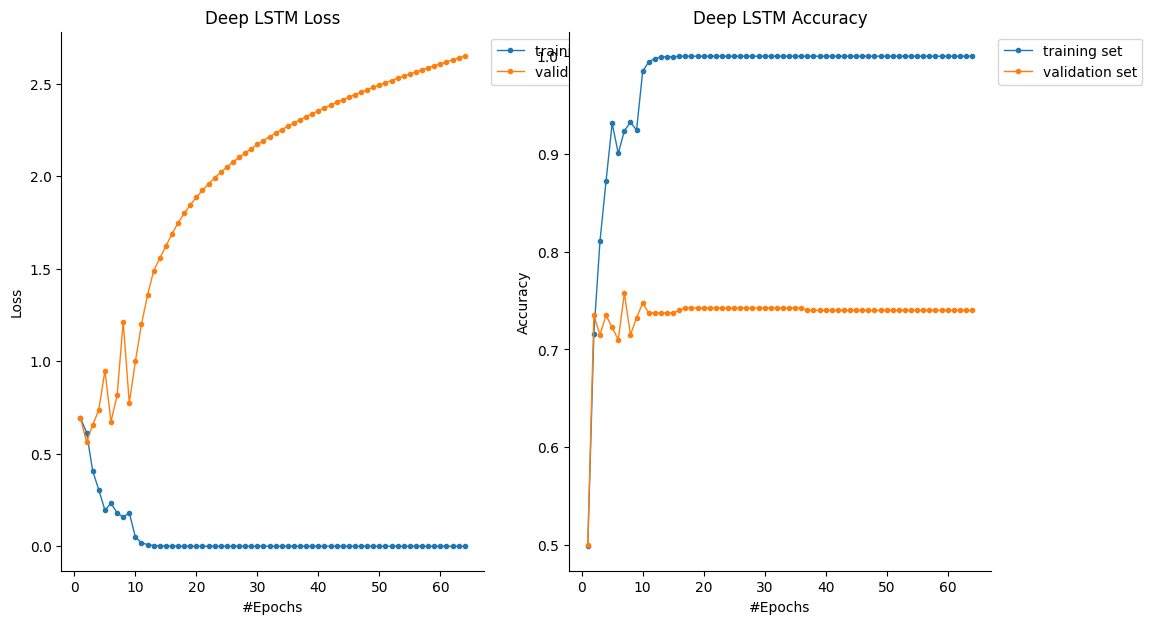

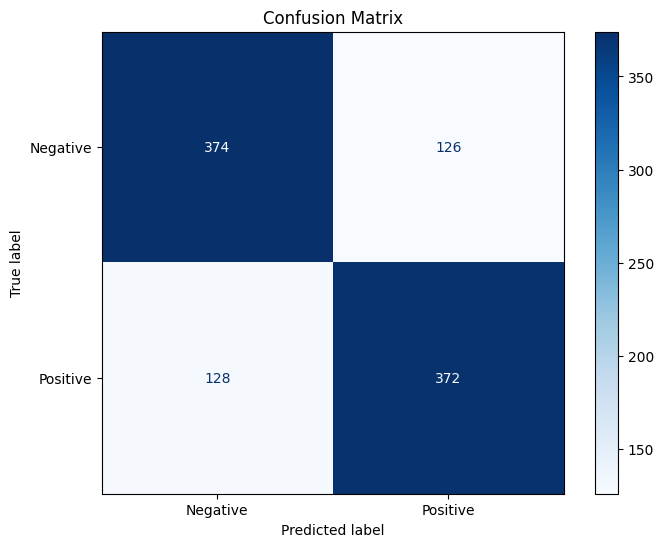

In [10]:
input_dim = X_train_tensor.shape[1]  
model = clf.DeepLSTMClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=3,
    fc_hidden_dim=64,
    output_dim=2,  # set this to the number of classes
    dropout=0.4,
    bidirectional=True
).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Deep LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Attention LSTM

LSTMWithAttentionClassifier(
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


676291 total parameters.
676291 training parameters.




  3%|▎         | 2/64 [00:00<00:12,  5.13it/s]

| Epoch: [1/64] | Train: Loss 0.6924 Accuracy : 0.5212 | Val: Loss 0.6806 Accuracy : 0.6575

| Epoch: [2/64] | Train: Loss 0.5961 Accuracy : 0.7075 | Val: Loss 0.5669 Accuracy : 0.7375



  5%|▍         | 3/64 [00:00<00:11,  5.19it/s]

| Epoch: [3/64] | Train: Loss 0.4572 Accuracy : 0.7919 | Val: Loss 0.5366 Accuracy : 0.7400



...

| Epoch: [61/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.9131 Accuracy : 0.7475

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.9207 Accuracy : 0.7475



 98%|█████████▊| 63/64 [00:13<00:00,  5.09it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.9281 Accuracy : 0.7475



100%|██████████| 64/64 [00:13<00:00,  4.77it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.9354 Accuracy : 0.7475


Test accuracy: 0.74


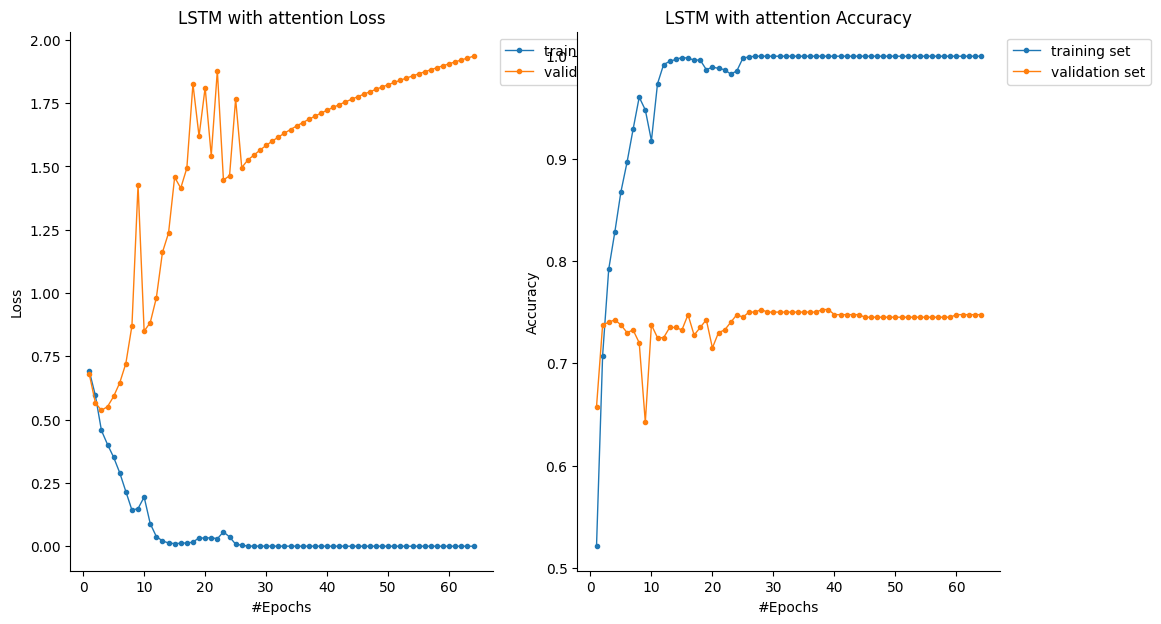

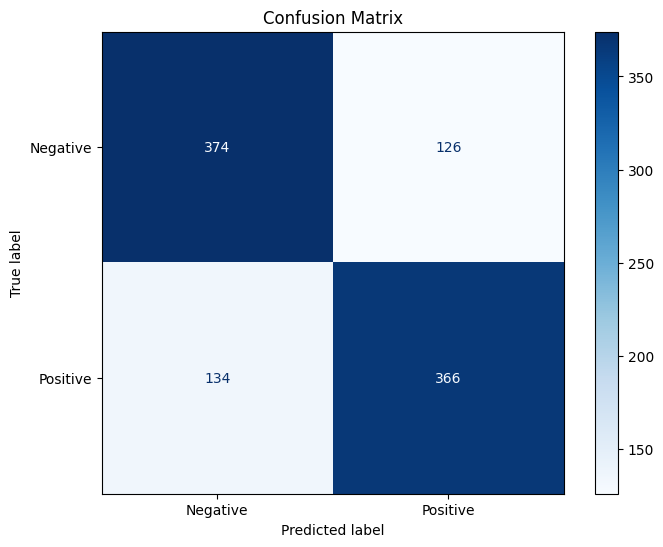

In [11]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMWithAttentionClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=2,
    output_dim=2,
    dropout=0.3,
    fc_hidden_dim=64,
    bidirectional=True
).to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM with attention", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])